## Normative Finance

## Uncertainty and Risk

In [2]:
S0 = 10
B0 = 10

In [4]:
M0 = np.array((S0, B0))
M0

array([10, 10])

In [6]:
K = 14.5

In [8]:
phi = np.linalg.solve(M1, C1)
phi

array([ 0.36666667, -0.16666667])

In [10]:
C0 = np.dot(M0, phi)
C0

2.0

In [11]:
def u(x):
    return np.sqrt(x)

In [13]:
np.dot(M0, phi_A) == np.dot(M0, phi_D)

True

In [15]:
D1 = np.dot(M1, phi_D)
D1

array([13.25,  9.5 ])

In [17]:
def EUT(x):
    return np.dot(P, u(x))

In [19]:
EUT(D1)

3.3611309730623735

In [21]:
w = 10

In [23]:
def EUT_(phi):
    x = np.dot(M1, phi)
    return EUT(x)

In [25]:
opt

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -3.3850159994933975
       x: [ 6.112e-01  3.888e-01]
     nit: 4
     jac: [-1.692e+00 -1.693e+00]
    nfev: 12
    njev: 4

In [27]:
np.dot(M0, opt['x'])

10.000000000000002

In [28]:
rS = S1 / S0 - 1
rS

array([ 1. , -0.5])

In [30]:
def mu(rX):
    return np.dot(P, rX)

In [32]:
mu(rB)

0.10000000000000009

In [34]:
mu(rM)

array([0.25, 0.1 ])

In [36]:
var(rS)

0.5625

In [38]:
def sigma(rX):
    return np.sqrt(var(rX))

In [40]:
sigma(rB)

0.0

In [42]:
phi = np.array((0.5, 0.5))

In [44]:
mu_phi(phi)

0.17500000000000004

In [46]:
var_phi(phi)

0.140625

In [48]:
sigma_phi(phi)

0.375

In [50]:
phi_mcs = np.random.random((2, 200))

In [52]:
mcs = np.array([(sigma_phi(phi), mu_phi(phi))
                for phi in phi_mcs])

In [54]:
P = np.ones(3) / 3
P

array([0.33333333, 0.33333333, 0.33333333])

In [56]:
T0 = 10
T1 = np.array((1, 12, 13))

In [58]:
M1 = np.array((S1, T1)).T
M1

array([[20,  1],
       [10, 12],
       [ 5, 13]])

In [60]:
mcs = np.array([(sigma_phi(phi), mu_phi(phi))
                for phi in phi_mcs])

In [62]:
cons = {'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}

In [64]:
min_var = minimize(sigma_phi, (0.5, 0.5),
                   constraints=cons, bounds=bnds)

In [66]:
def sharpe(phi):
    return mu_phi(phi) / sigma_phi(phi)

In [68]:
max_sharpe

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -0.27216540990401067
       x: [ 6.673e-01  3.327e-01]
     nit: 9
     jac: [ 1.205e-04 -2.417e-04]
    nfev: 29
    njev: 9

In [70]:
cons = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1},
        {'type': 'eq', 'fun': lambda phi: mu_phi(phi) - target}]

In [72]:
targets = np.linspace(mu_phi(min_var['x']), 0.16)

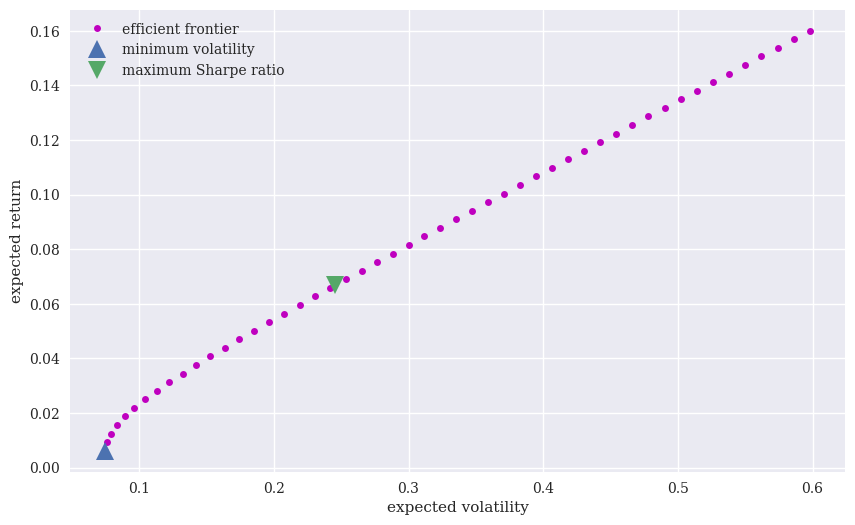

In [74]:
plt.figure(figsize=(10, 6))
plt.plot(frontier[:, 0], frontier[:, 1], 'mo', ms=5,
         label='efficient frontier')
plt.plot(sigma_phi(min_var['x']), mu_phi(min_var['x']),
         '^', ms=12.5, label='minimum volatility')
plt.plot(sigma_phi(max_sharpe['x']), mu_phi(max_sharpe['x']),
         'v', ms=12.5, label='maximum Sharpe ratio')
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.legend();

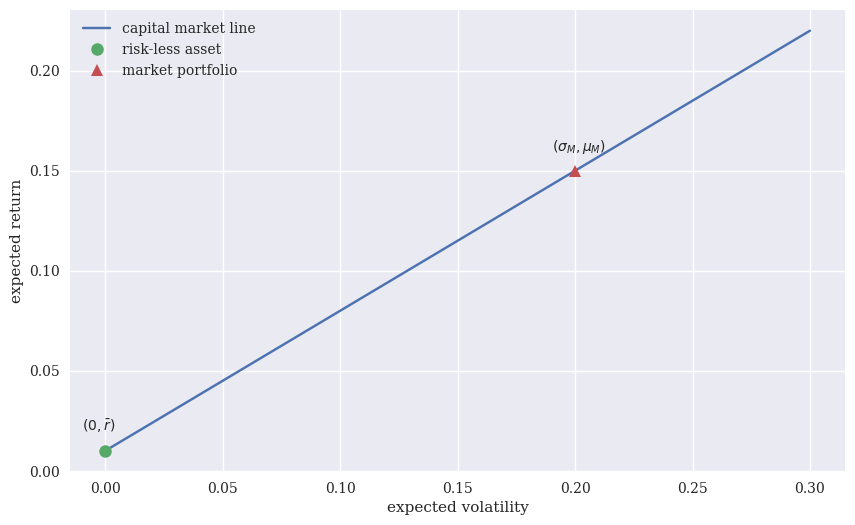

In [75]:
plt.figure(figsize=(10, 6))
plt.plot((0, 0.3), (0.01, 0.22), label='capital market line')
plt.plot(0, 0.01, 'o', ms=9, label='risk-less asset')
plt.plot(0.2, 0.15, '^', ms=9, label='market portfolio')
plt.annotate('$(0, \\bar{r})$', (0, 0.01), (-0.01, 0.02))
plt.annotate('$(\sigma_M, \mu_M)$', (0.2, 0.15), (0.19, 0.16))
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.legend();

In [77]:
mu_M = mu_phi(phi_M)
mu_M

0.10666666666666666

In [79]:
r = 0.0025

In [81]:
def U(p):
    mu, sigma = p
    return mu - 1 / 2 * (sigma ** 2 + mu ** 2)

In [83]:
opt = minimize(lambda p: -U(p), (0.1, 0.3), constraints=cons)

In [85]:
from sympy import *

init_printing(use_unicode=False, use_latex=False)

In [87]:
sol = solve('mu - b / 2 * (sigma ** 2 + mu ** 2) - v', mu)

In [89]:
u1 = sol[0].subs({'b': 1, 'v': 0.1})
u1

       ______________
      /            2 
1 - \/  0.8 - sigma  

In [91]:
f1 = lambdify(sigma, u1)
f2 = lambdify(sigma, u2)

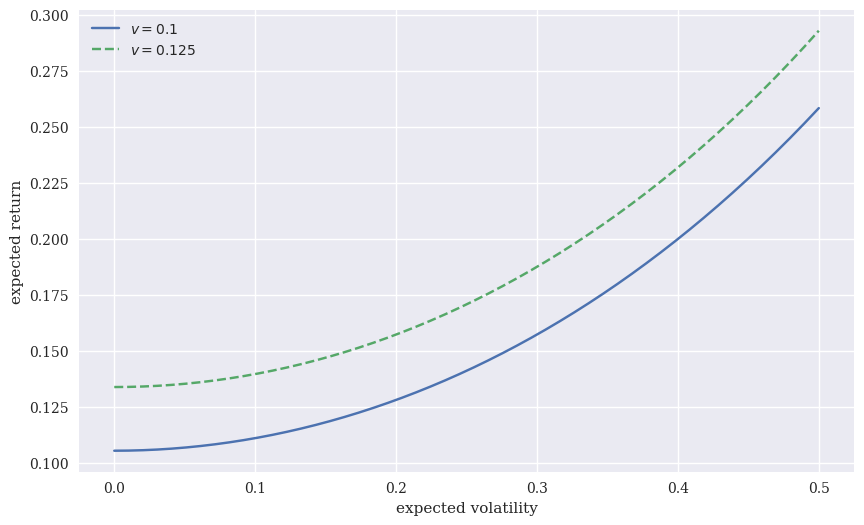

In [93]:
plt.figure(figsize=(10, 6))
plt.plot(sigma_, u1_, label='$v=0.1$')
plt.plot(sigma_, u2_, '--', label='$v=0.125$')
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.legend();

In [95]:
f = lambdify(sigma, u)

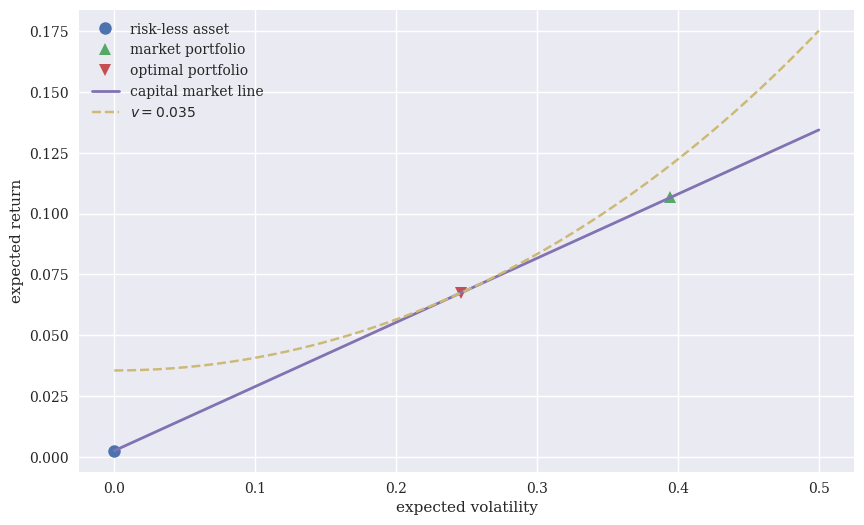

In [97]:
plt.figure(figsize=(10, 6))
plt.plot(0, r, 'o', ms=9, label='risk-less asset')
plt.plot(sigma_M, mu_M, '^', ms=9, label='market portfolio')
plt.plot(opt['x'][1], opt['x'][0], 'v', ms=9, label='optimal portfolio')
plt.plot((0, 0.5), (r, r + (mu_M - r) / sigma_M * 0.5),
         label='capital market line', lw=2.0)
plt.plot(sigma_, u_, '--', label='$v={}$'.format(-round(opt['fun'], 3)))
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.legend();

In [98]:
M1

array([[20,  1],
       [10, 12],
       [ 5, 13]])

In [100]:
V1 = np.array((12, 15, 7))

In [102]:
np.dot(M1, reg)

array([12.78363525, 12.14532872,  9.57480155])

In [104]:
V0 = np.dot(M0, reg)
V0

11.144718094850402

In [106]:
M0_ = np.array((S0, T0, U0))

In [108]:
M1_

array([[20,  1, 12],
       [10, 12,  5],
       [ 5, 13, 11]])

In [110]:
reg = np.linalg.lstsq(M1_, V1, rcond=-1)[0]
reg

array([ 0.9575179 ,  0.72553699, -0.65632458])

In [112]:
V0_ = np.dot(M0_, reg)
V0_

10.267303102625304